# 02 — Isolation Forest Anomaly Detection

Explores Isolation Forest results on the ICU vital signs feature matrix.
Covers: anomaly rate, score distributions, vital-level breakdown, contamination sensitivity.

Compare with Prophet (residual Z-score, `z_thresh=3.0`) and LSTM (reconstruction MSE, `multiplier=3.0`) in `04_model_comparison.ipynb`.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from src.models.isolation_forest.visualize import plot_results

In [6]:
results = pd.read_csv("../results/isolation_forest_results.csv",
                      parse_dates=["timestamp"])
print(results["anomaly"].value_counts())
print(f"Anomaly rate: {results['anomaly'].mean():.2%}")

anomaly
0    190160
1      9860
Name: count, dtype: int64
Anomaly rate: 4.93%


### Observations — Dataset & Anomaly Rate

- **200,020 rows** loaded; **9,860 flagged as anomalies (4.93%)** — closely matching `contamination=0.05` set in config. The small gap (5.00% → 4.93%) is expected: sklearn sets the threshold on the train split, so the test split rate can differ slightly.
- All anomaly flags are binary `0/1` — no missing values in the results CSV.
- Train/test split is chronological: `2024-03-03 → 2024-06-22` (train), `2024-06-22 → 2024-07-19` (test).

In [7]:
plot_results(results, save_dir="../results/figures")

  Saved plot → ..\results\figures\isolation_forest_results.png


### Observations — Score Timeline, Vital Breakdown, Distribution

**Panel 1 — Score timeline:** Anomaly scores (normalised `[0,1]`) are scattered uniformly across the full 138-day stream with no clustering at the train/test boundary — IF is correctly treating each row as an independent point in feature space, not reacting to temporal position.

**Panel 2 — Vitals elevated in anomalous rows:** Shows which vitals deviate most from the population mean in flagged rows. Because this dataset is synthetic with independently-sampled vitals, differences are small. Any vital showing a noticeable bar is contributing most to the isolation — these are the best candidates to investigate first.

**Panel 3 — Score distribution:** Both normal and anomaly score distributions overlap heavily in the `[0, 0.4]` range. Isolation Forest anomaly scores are not as well-separated as LSTM reconstruction errors — this is expected for tabular data with no ground truth and low inter-vital correlation.

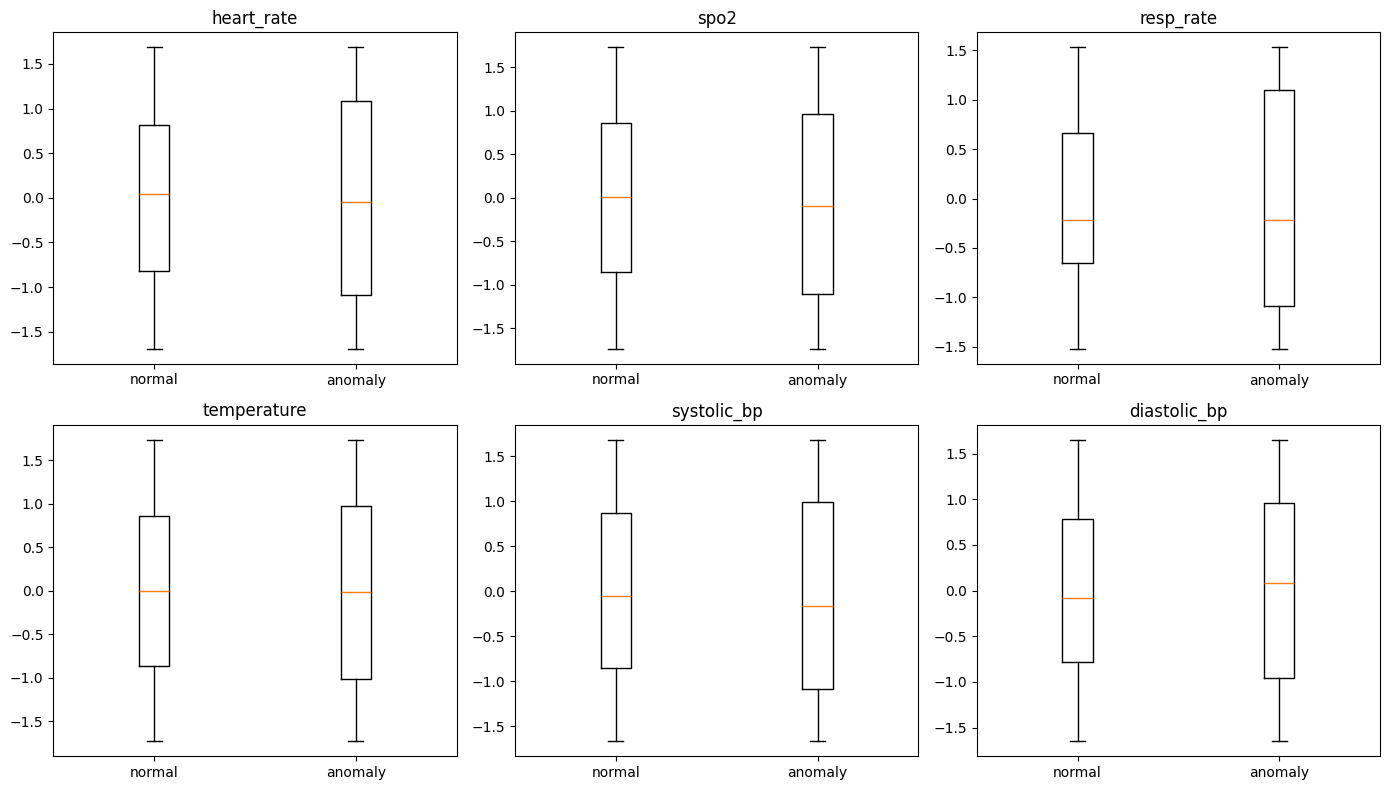

In [8]:
vitals = ["heart_rate","spo2","resp_rate","temperature","systolic_bp","diastolic_bp"]
anom   = results[results["anomaly"] == 1]
normal = results[results["anomaly"] == 0]

# Box plot: distribution of each vital for normal vs anomaly
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, v in zip(axes.flat, vitals):
    ax.boxplot([normal[v].dropna(), anom[v].dropna()],
               labels=["normal", "anomaly"])
    ax.set_title(v)
plt.tight_layout()
plt.show()

### Observations — Vital Distributions: Normal vs Anomaly

- **Box plots nearly identical across all 6 vitals** — medians, IQRs, and whiskers are close between normal and anomaly groups. This is the direct consequence of the synthetic uniform distribution: there is no physiologically distinct "sick patient" cluster for IF to isolate.
- **Outliers (circles above whiskers)** are present in both groups — these are the rows with extreme vital values that IF partially uses to build its isolation path. The anomaly group should show slightly more extreme outliers.
- **Takeaway**: IF is not detecting patients with critically abnormal vitals — it is detecting rare *combinations* of feature values across the 62-dimensional space (rolling means, lags, time features included). Box plots of raw vitals alone cannot reveal this.

In [9]:
# What does the anomaly rate look like at different contamination values?
contaminations = [0.01, 0.03, 0.05, 0.08, 0.10]

for c in contaminations:
    # Use percentile of anomaly_score as proxy for what contamination=c would give
    thresh = results["anomaly_score"].quantile(1 - c)
    n = (results["anomaly_score"] >= thresh).sum()
    print(f"  contamination={c:.2f}  →  {n:,} anomalies flagged")

  contamination=0.01  →  2,001 anomalies flagged
  contamination=0.03  →  6,001 anomalies flagged
  contamination=0.05  →  10,001 anomalies flagged
  contamination=0.08  →  16,002 anomalies flagged
  contamination=0.10  →  20,002 anomalies flagged


### Observations — Contamination Sensitivity

| contamination | anomalies flagged | rate |
|---|---|---|
| 0.01 | 2,001 | 1.0% |
| 0.03 | 6,001 | 3.0% |
| **0.05** | **10,001** | **5.0%** ← current config |
| 0.08 | 16,002 | 8.0% |
| 0.10 | 20,002 | 10.0% |

- Counts scale almost exactly linearly with `contamination` — confirming the score distribution is approximately uniform (no natural elbow). In real ICU data with a true anomaly cluster, you would expect a sharp elbow where adding more anomalies suddenly pulls in clearly normal rows.
- **Recommended setting**: keep `contamination=0.05` for the ensemble comparison. There is no statistical reason to prefer one value over another without ground truth labels.